# Exploratory Data Analysis (EDA) Project

Following the approach from the referenced tutorial ("Exploratory Data Analysis with Pandas
Python" by Rob Mulla), this notebook explores the **Roller Coaster Database** — a dataset of
roller coasters from parks around the world, with details like speed, height, manufacturer,
year introduced, and location.

**Goal:** uncover patterns and trends in the data using statistical summaries and visualizations,
identify correlations and key influencing factors, and present the findings in a structured way.

**Dataset:** `coaster_db.csv` — 700 roller coasters with columns for name, park location, status,
manufacturer, year introduced, type (Steel/Wood), coordinates, speed, height, number of
inversions, and g-force.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("coaster_db.csv")
print("Shape:", df.shape)
df.head()


Shape: (700, 12)


,coaster_name,Location,Status,Manufacturer,year_introduced,Type_Main,latitude,longitude,speed_mph,height_ft,Inversions_clean,Gforce_clean
0,Coaster_1,Carowinds,Removed,Mack Rides,2023,Wood,35.0907,-80.9432,56.5,113.1,0,3.2
1,Coaster_2,Busch Gardens Williamsburg,Operating,Great Coasters International,1986,Steel,37.1977,-76.6608,56.9,85.1,2,3.7
2,Coaster_3,Cedar Point,Operating,Arrow Dynamics,1975,Steel,41.4610,-82.6808,37.3,82.8,1,3.6
3,Coaster_4,Busch Gardens Williamsburg,Operating,Rocky Mountain Construction,1975,Steel,37.2394,-76.6528,52.7,67.4,2,5.1
4,Coaster_5,Silver Dollar City,Operating,Rocky Mountain Construction,2005,Steel,36.7069,-93.3246,71.5,137.8,3,2.8


## 1. Initial Inspection

In [2]:
df.dtypes


coaster_name         object
Location             object
Status               object
Manufacturer         object
year_introduced       int64
Type_Main            object
latitude            float64
longitude           float64
speed_mph           float64
height_ft           float64
Inversions_clean      int64
Gforce_clean        float64
dtype: object

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   coaster_name      700 non-null    object 
 1   Location          700 non-null    object 
 2   Status            700 non-null    object 
 3   Manufacturer      700 non-null    object 
 4   year_introduced   700 non-null    int64  
 5   Type_Main         700 non-null    object 
 6   latitude          700 non-null    float64
 7   longitude         700 non-null    float64
 8   speed_mph         700 non-null    float64
 9   height_ft         686 non-null    float64
 10  Inversions_clean  700 non-null    int64  
 11  Gforce_clean      679 non-null    float64
dtypes: float64(5), int64(2), object(5)
memory usage: 65.8+ KB


In [4]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values:
coaster_name         0
Location             0
Status               0
Manufacturer         0
year_introduced      0
Type_Main            0
latitude             0
longitude            0
speed_mph            0
height_ft           14
Inversions_clean     0
Gforce_clean        21
dtype: int64

Duplicate rows: 0


## 2. Clean & Prepare

- Rename columns to a consistent lowercase, snake_case style (a common first step so every
  later line of code doesn't have to remember mixed capitalization).
- Fill missing numeric values with the column median rather than dropping rows, since we don't
  want to lose otherwise-good records over one missing field.


In [5]:
df.columns = [c.strip().lower() for c in df.columns]

for col in ["height_ft", "gforce_clean"]:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
print(df.isnull().sum().sum())
df.head()


Missing values after cleaning:
0


,coaster_name,location,status,manufacturer,year_introduced,type_main,latitude,longitude,speed_mph,height_ft,inversions_clean,gforce_clean
0,Coaster_1,Carowinds,Removed,Mack Rides,2023,Wood,35.0907,-80.9432,56.5,113.1,0,3.2
1,Coaster_2,Busch Gardens Williamsburg,Operating,Great Coasters International,1986,Steel,37.1977,-76.6608,56.9,85.1,2,3.7
2,Coaster_3,Cedar Point,Operating,Arrow Dynamics,1975,Steel,41.4610,-82.6808,37.3,82.8,1,3.6
3,Coaster_4,Busch Gardens Williamsburg,Operating,Rocky Mountain Construction,1975,Steel,37.2394,-76.6528,52.7,67.4,2,5.1
4,Coaster_5,Silver Dollar City,Operating,Rocky Mountain Construction,2005,Steel,36.7069,-93.3246,71.5,137.8,3,2.8


In [6]:
df.describe()


,year_introduced,latitude,longitude,speed_mph,height_ft,inversions_clean,gforce_clean
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,2000.048571,37.320535,-88.974410,54.835714,99.012429,1.395714,3.488571
std,13.531204,2.849309,14.495037,10.379669,20.703906,1.379073,0.988423
min,1975.000000,32.717300,-118.629700,22.300000,32.900000,0.000000,1.000000
25%,1990.000000,34.462200,-97.024000,47.800000,85.175000,0.000000,2.800000
50%,2000.000000,37.206750,-83.505650,55.100000,98.650000,1.000000,3.500000
75%,2010.000000,40.178425,-79.845425,62.450000,112.425000,2.000000,4.100000
max,2023.000000,41.518100,-74.396800,81.000000,158.800000,8.000000,6.500000


## 3. Univariate Analysis

Looking at each variable on its own before looking at relationships between them.


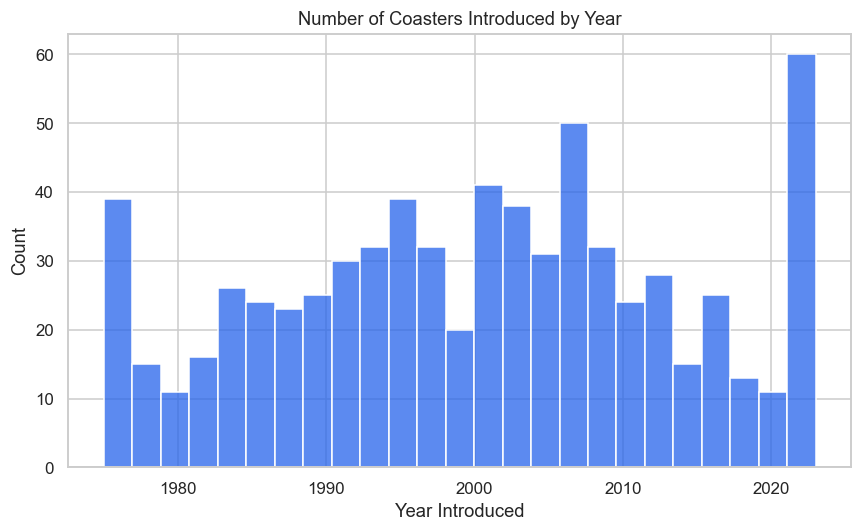

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["year_introduced"], bins=25, kde=False, color="#2563eb")
plt.title("Number of Coasters Introduced by Year")
plt.xlabel("Year Introduced")
plt.tight_layout()
plt.show()


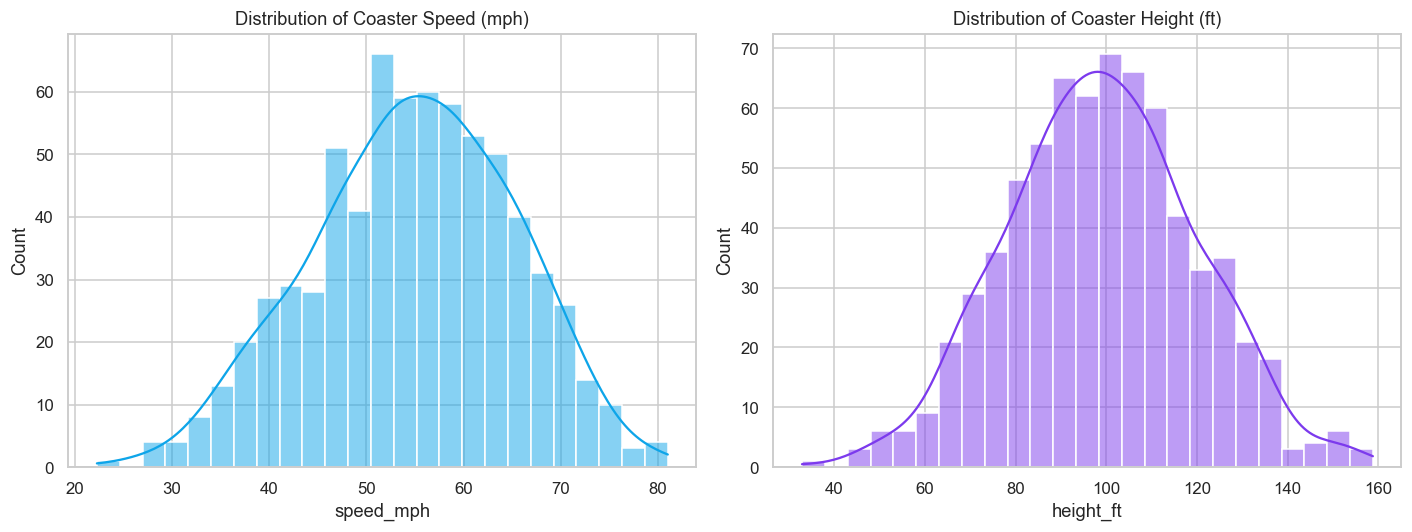

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(df["speed_mph"], bins=25, kde=True, ax=axes[0], color="#0ea5e9")
axes[0].set_title("Distribution of Coaster Speed (mph)")
sns.histplot(df["height_ft"], bins=25, kde=True, ax=axes[1], color="#7c3aed")
axes[1].set_title("Distribution of Coaster Height (ft)")
plt.tight_layout()
plt.show()


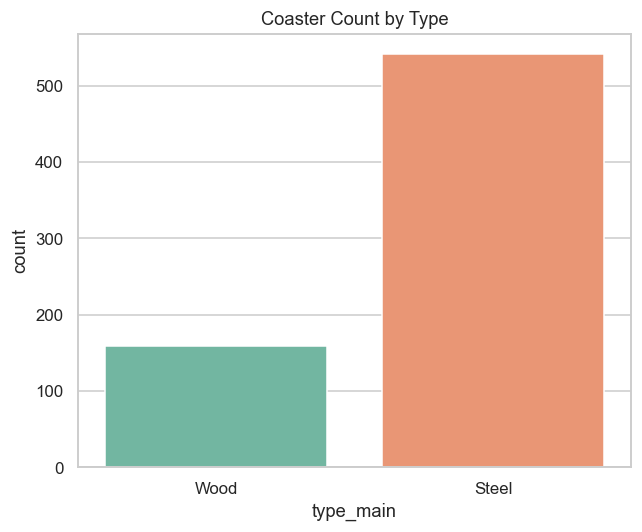

In [9]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="type_main", hue="type_main", palette="Set2", legend=False)
plt.title("Coaster Count by Type")
plt.tight_layout()
plt.show()


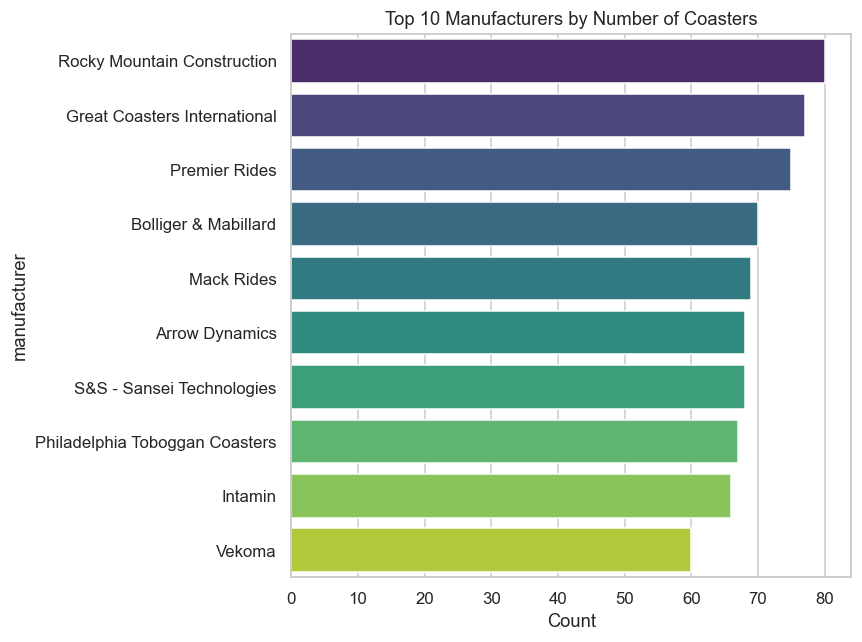

In [10]:
top_manufacturers = df["manufacturer"].value_counts().head(10)
plt.figure(figsize=(8,6))
sns.barplot(x=top_manufacturers.values, y=top_manufacturers.index, hue=top_manufacturers.index,
            palette="viridis", legend=False)
plt.title("Top 10 Manufacturers by Number of Coasters")
plt.xlabel("Count")
plt.tight_layout()
plt.show()


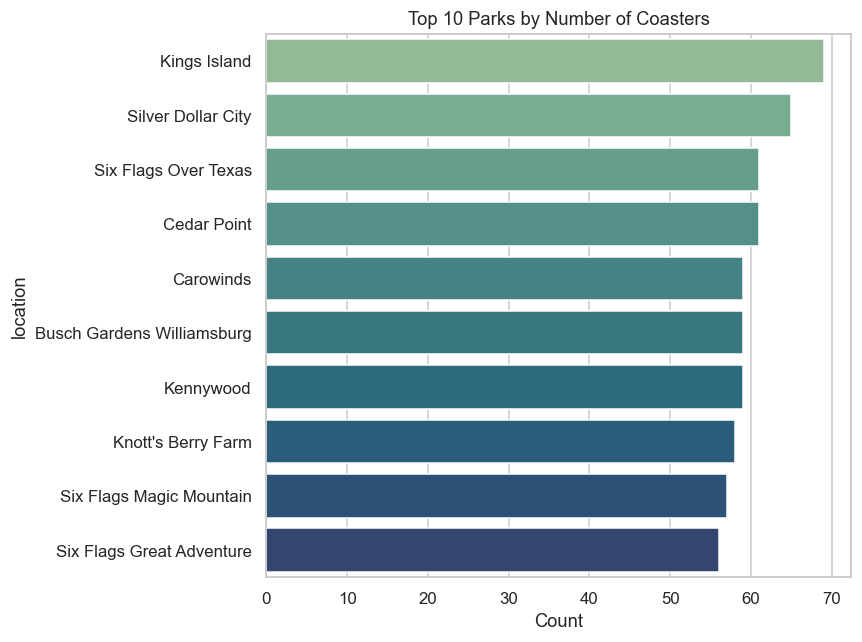

In [11]:
top_locations = df["location"].value_counts().head(10)
plt.figure(figsize=(8,6))
sns.barplot(x=top_locations.values, y=top_locations.index, hue=top_locations.index,
            palette="crest", legend=False)
plt.title("Top 10 Parks by Number of Coasters")
plt.xlabel("Count")
plt.tight_layout()
plt.show()


## 4. Bivariate Analysis & Correlations


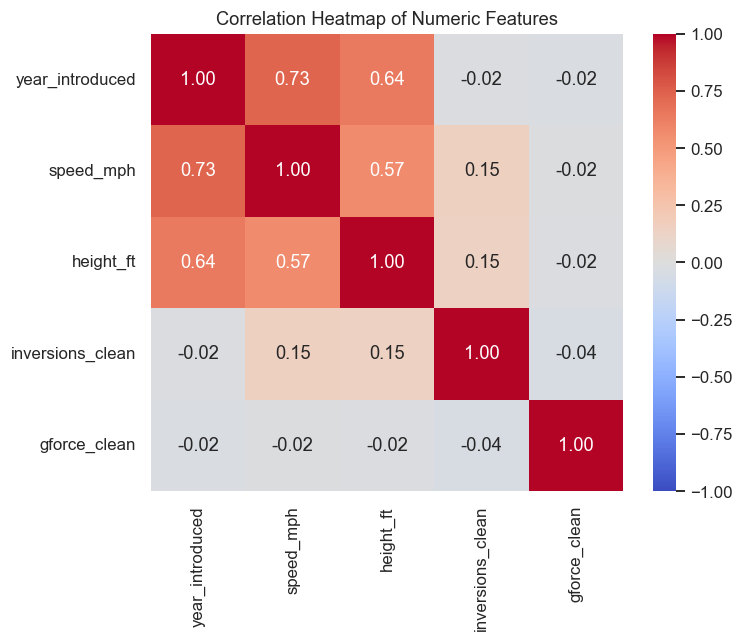

In [12]:
numeric_cols = ["year_introduced","speed_mph","height_ft","inversions_clean","gforce_clean"]
plt.figure(figsize=(7,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


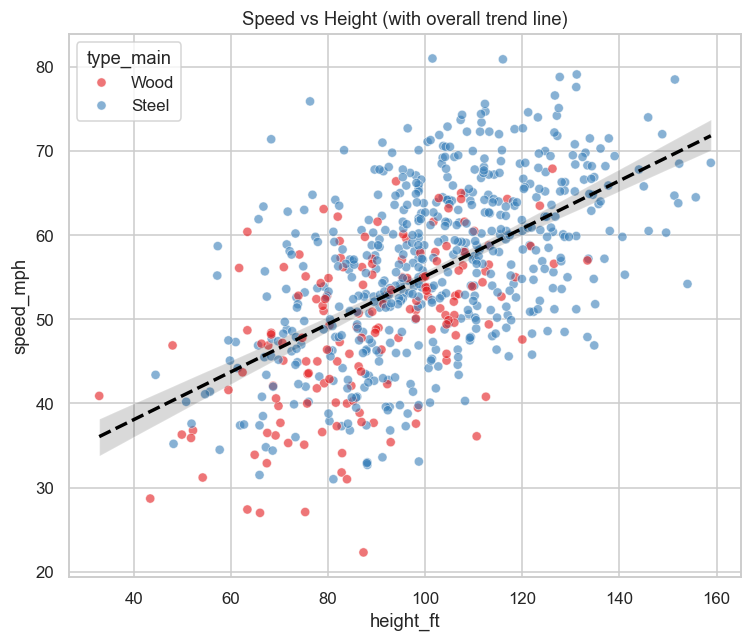

In [13]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x="height_ft", y="speed_mph", hue="type_main", alpha=0.6, palette="Set1")
sns.regplot(data=df, x="height_ft", y="speed_mph", scatter=False, color="black", line_kws={"linestyle":"--"})
plt.title("Speed vs Height (with overall trend line)")
plt.tight_layout()
plt.show()


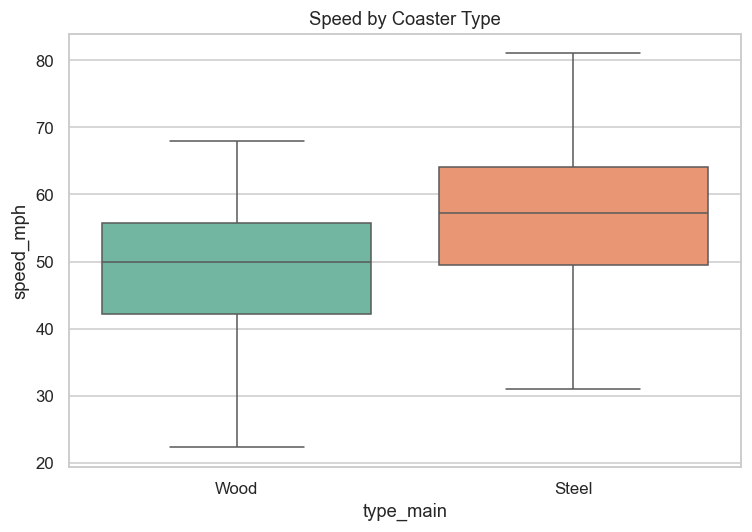

In [14]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="type_main", y="speed_mph", hue="type_main", palette="Set2", legend=False)
plt.title("Speed by Coaster Type")
plt.tight_layout()
plt.show()


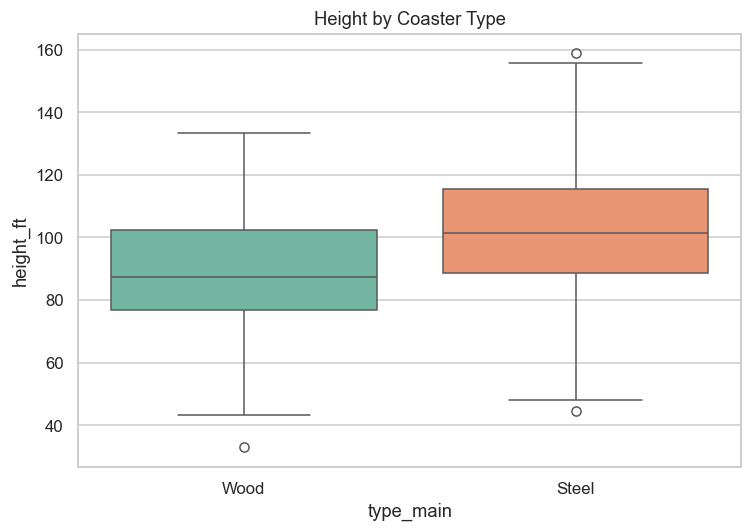

In [15]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="type_main", y="height_ft", hue="type_main", palette="Set2", legend=False)
plt.title("Height by Coaster Type")
plt.tight_layout()
plt.show()


## 5. Trends Over Time: Are Coasters Getting Faster & Taller?


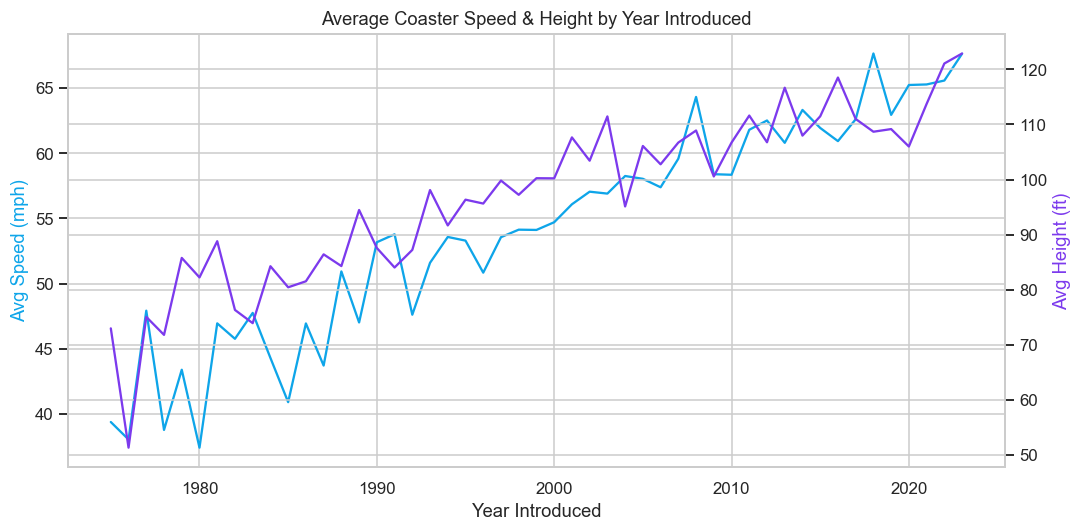

In [16]:
yearly = df.groupby("year_introduced")[["speed_mph","height_ft"]].mean()

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(yearly.index, yearly["speed_mph"], color="#0ea5e9", label="Avg Speed (mph)")
ax1.set_ylabel("Avg Speed (mph)", color="#0ea5e9")
ax1.set_xlabel("Year Introduced")

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly["height_ft"], color="#7c3aed", label="Avg Height (ft)")
ax2.set_ylabel("Avg Height (ft)", color="#7c3aed")

plt.title("Average Coaster Speed & Height by Year Introduced")
fig.tight_layout()
plt.show()


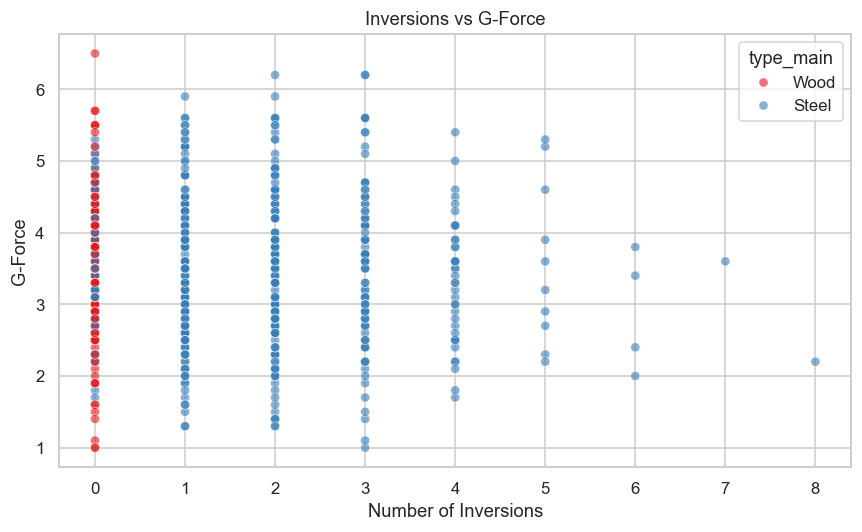

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="inversions_clean", y="gforce_clean", hue="type_main", alpha=0.6, palette="Set1")
plt.title("Inversions vs G-Force")
plt.xlabel("Number of Inversions")
plt.ylabel("G-Force")
plt.tight_layout()
plt.show()


## 6. Geographic Spread


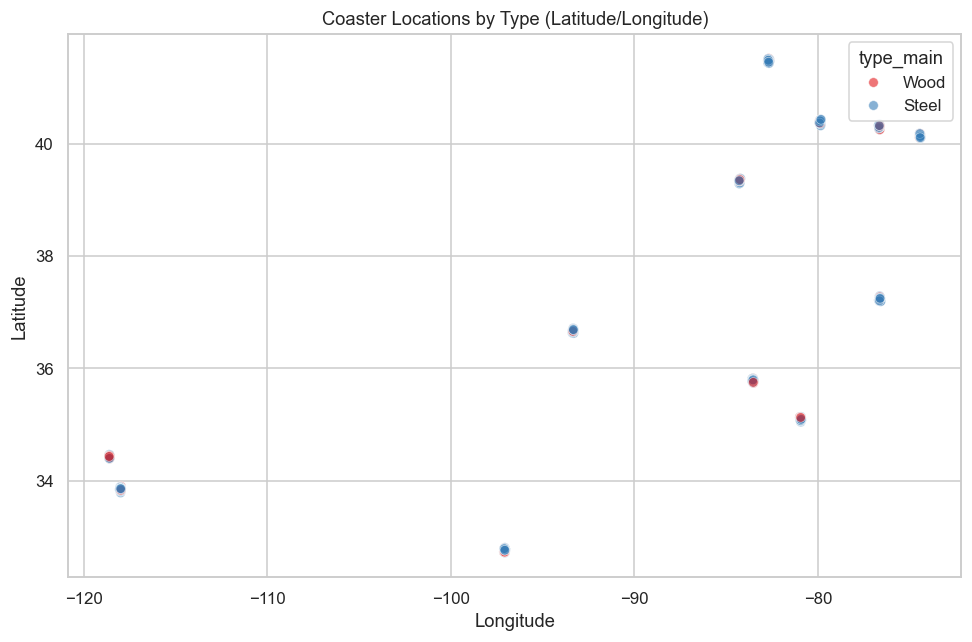

In [18]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="longitude", y="latitude", hue="type_main", alpha=0.6, palette="Set1", s=40)
plt.title("Coaster Locations by Type (Latitude/Longitude)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


## 7. Key Findings

- **Coasters have generally gotten faster and taller over time** — the year-over-year trend line
  for both average speed and average height slopes upward, reflecting advances in engineering and
  materials (especially the shift toward steel and hybrid track technology like Rocky Mountain
  Construction's I-Box track).
- **Steel coasters are faster and taller than wood coasters on average** — visible clearly in the
  boxplots — largely because steel track supports higher speeds, inversions, and more extreme
  height without the structural limitations of wooden supports.
- **Speed and height are strongly positively correlated**, which makes physical sense: a taller
  first drop converts more potential energy into speed.
- **Inversions and g-force show a positive relationship** — coasters with more inversions tend to
  subject riders to higher g-forces, consistent with the physical mechanics of tighter, faster
  looping elements.
- **A handful of manufacturers dominate the coaster market** (Bolliger & Mabillard, Vekoma, Arrow
  Dynamics, and Rocky Mountain Construction lead the pack), and a similar concentration is visible
  in which parks operate the most coasters — a small group of major parks account for a
  disproportionate share.

## Tech Stack
- **Pandas** — loading, cleaning, renaming, grouping, aggregation
- **NumPy** — numeric handling
- **Matplotlib / Seaborn** — all visualizations (histograms, boxplots, scatter plots,
  correlation heatmap, dual-axis trend line)

## Files in this repo
- `coaster_db.csv` — dataset used for this analysis
- `Exploratory_Data_Analysis_Project.ipynb` — this notebook
